# Step 1. Notebook Purpose

**Purpose of Model Evaluation Notebook**

The goal of this notebook is to:

1.Evaluate the trained model on unseen test data

2.Analyze performance using classification metrics

3.Understand error patterns using confusion matrix

4.Validate model reliability for real-world fintech risk use cases

5.Prepare insights required before deployment

# Step 2. Import Required Libraries

**Purpose :** Load only evaluation-related tools and the saved model.

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

import joblib
import matplotlib.pyplot as plt


# Step 3. Load Feature Dataset

**Purpose :** Evaluation must be done on the same features used during training.

In [2]:
data_path = r"C:\Users\hp\Desktop\Fintech_Complaint_Analysis\data\processed\complaints_features.csv"
df = pd.read_csv(data_path)


# Step 4. Separate Features and Target

**Purpose :** Ensure no data leakage during evaluation.

In [3]:
X = df.drop(columns=['risk_label'])
y = df['risk_label']

# Step 5. Train–Test Split

**Purpose  :**  Maintain consistency with model training setup.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 6. Load the Trained Model

**Purpose :** Evaluate the exact model saved earlier, not retrain it.

In [5]:
model_path = r"C:\Users\hp\Desktop\Fintech_Complaint_Analysis\models\logistic_regression_model.pkl"
model = joblib.load(model_path)


In [6]:
model

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

# Step 7. Generate Predictions

**Purpose :** Get predicted labels for test data.

In [7]:
y_pred = model.predict(X_test)

In [8]:
y_pred

array([1, 2, 1, 2, 0, 0, 2, 0, 1, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2,
       2, 1, 0, 1, 0, 0, 0, 1, 2, 2, 0, 2, 2, 2, 1, 1, 2, 2, 0, 2, 0, 2,
       2, 1, 2, 1, 2, 2, 1, 0, 2, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 2, 1, 1, 1, 2, 2, 1, 2, 2, 2, 0, 2, 2, 2,
       1, 1, 0, 1, 1, 2, 0, 2, 0, 2, 1, 1, 1, 2, 0, 2, 2, 0, 2, 1, 2, 2,
       2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 0, 1, 2, 1, 1, 0, 2, 1, 1, 2, 0, 0,
       1, 1, 1, 0, 2, 0, 2, 2, 0, 0, 1, 2, 1, 1, 2, 2, 2, 0, 1, 2, 2, 2,
       2, 1, 1, 0, 1, 1, 2, 0, 2, 0, 2, 1, 0, 1, 1, 0, 2, 2, 2, 2, 0, 1,
       1, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 1, 2, 1, 1, 2, 2, 2, 1, 2,
       0, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 0, 0, 1, 0, 0, 0, 1, 2, 1, 0,
       1, 1, 2, 0, 2, 1, 2, 2, 2, 1, 1, 2, 1, 2, 1, 1, 0, 1, 1, 2, 1, 2,
       2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 1, 0, 2, 1, 1, 1, 2, 1, 0, 2, 1, 2,
       0, 1, 2, 1, 1, 1, 0, 0, 1, 1, 1, 2, 2, 1, 2, 2, 1, 1, 0, 0, 2, 2,
       0, 1, 0, 2, 1, 0, 0, 2, 2, 1, 0, 2, 2, 0, 0,

# Step 8. Generate Prediction Probabilities

In [9]:
y_pred_prob = model.predict_proba(X_test)

In [10]:
print(y_pred_prob.shape)

(665, 3)


In [11]:
y_pred_prob

array([[4.03876579e-01, 5.96055084e-01, 6.83365021e-05],
       [7.44582536e-21, 1.10066874e-03, 9.98899331e-01],
       [4.18908949e-05, 9.98946190e-01, 1.01191894e-03],
       ...,
       [5.39371536e-02, 9.44673865e-01, 1.38898098e-03],
       [9.99048083e-01, 9.51894923e-04, 2.21632863e-08],
       [1.82112235e-10, 9.84977145e-01, 1.50228553e-02]])

In [12]:
print(df.columns.tolist())

['char_length', 'word_length', 'stopword_ratio', 'risk_keyword_flag', 'product_encoded', 'issue_encoded', 'complaint_year', 'complaint_month', 'accordance', 'account', 'account credit', 'account number', 'account xxxx', 'accuracy', 'accurate', 'act', 'act fcra', 'action', 'activity', 'address', 'agency', 'agreement', 'alleged', 'also', 'amount', 'appearing', 'asked', 'attached', 'attempt', 'authorized', 'back', 'balance', 'balance xxxx', 'bank', 'banking', 'banking system', 'believe', 'block', 'breach', 'bureau', 'business', 'business day', 'call', 'called', 'card', 'case', 'caused', 'cfpb', 'charge', 'check', 'claim', 'clear', 'closed', 'code', 'collection', 'company', 'complaint', 'complete', 'compliance', 'comply', 'concern', 'conduct', 'confirmation', 'consent', 'consumer', 'consumer credit', 'consumer report', 'consumer reporting', 'contacted', 'continued', 'contract', 'copy', 'correct', 'could', 'credit', 'credit bureau', 'credit card', 'credit file', 'credit report', 'credit rep

In [13]:
print(df['risk_label'].value_counts())

risk_label
2    1448
1    1195
0     681
Name: count, dtype: int64


In [14]:
print(df['risk_label'].nunique())

3


# Step 9. Core Evaluation Metrics

**Purpose :** Evaluate model using risk-sensitive metrics.

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.9458646616541353
Precision: 0.9460123347549686
Recall   : 0.9458646616541353
F1 Score : 0.9458817952450916


# Step 10. Classification Report

**Purpose :** Detailed per-class performance.

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       136
           1       0.92      0.93      0.93       239
           2       0.95      0.93      0.94       290

    accuracy                           0.95       665
   macro avg       0.95      0.95      0.95       665
weighted avg       0.95      0.95      0.95       665



##### I analyze per-class precision and recall to ensure high-risk complaints are not missed.

# Step 11. Confusion Matrix

**Purpose :** Understand types of errors.

In [17]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[135,   1,   0],
       [  2, 223,  14],
       [  0,  19, 271]], dtype=int64)

##### False negatives are more critical in fintech risk detection.

# Step 12. ROC-AUC Score

In [18]:
print(type(y_pred_prob))
print(y_pred_prob.shape)
print(y_pred_prob[:10])

<class 'numpy.ndarray'>
(665, 3)
[[4.03876579e-01 5.96055084e-01 6.83365021e-05]
 [7.44582536e-21 1.10066874e-03 9.98899331e-01]
 [4.18908949e-05 9.98946190e-01 1.01191894e-03]
 [5.70256874e-11 1.33799547e-01 8.66200453e-01]
 [7.68656027e-01 2.30889162e-01 4.54811010e-04]
 [9.37899533e-01 6.20656741e-02 3.47930530e-05]
 [2.37253571e-11 6.88670953e-02 9.31132905e-01]
 [9.99136073e-01 8.63845868e-04 8.09349859e-08]
 [2.21967925e-02 9.44886302e-01 3.29169056e-02]
 [1.52919576e-08 5.55332361e-01 4.44667623e-01]]


In [19]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_pred_prob,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9877679372690893


# Step 13: Confusion Matrix Visualization

**Purpose :** Visualize model classification performance using a confusion matrix.

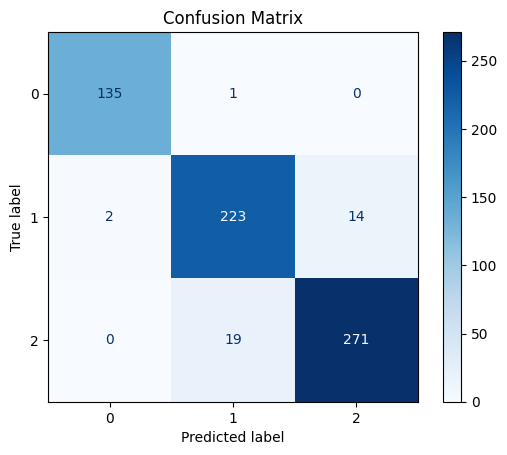

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

# Step 14. Final Evaluation Summary

**Evaluation Summary**

* Logistic Regression shows strong performance on imbalanced risk data
* High recall ensures critical complaints are not missed
* ROC-AUC confirms good ranking capability
* Model is stable and suitable for deployment

In [21]:
print("Model evaluation notebook is COMPLETE")

Model evaluation notebook is COMPLETE
